# K-Nearest Neighbors (KNN) — Complete Guide

### KNN is a supervised machine learning algorithm used mainly for:

* Classification
* Regression
* Pattern recognition
* Recommendation-style similarity problems

#### The main idea is simple:

* To predict a new data point, KNN looks at the K most similar data points around it and uses their values to make the prediction.

# 1. KNN Basic Idea

* Suppose we have customers:

| Customer | Age | Income | Purchased |
| -------- | --: | -----: | --------- |
| A        |  22 |    25k | No        |
| B        |  25 |    30k | No        |
| C        |  45 |    80k | Yes       |
| D        |  50 |    90k | Yes       |


###  For a new customer:
* Age = 43
* Income = 75k

### KNN finds the closest customers.

## If:

* K = 3

### and the 3 nearest customers are:

* Yes
* Yes
* No

### then majority voting gives:

* Prediction = Yes

# 2. Why is it called K-Nearest Neighbors?

#### Break the name into three parts:

* K

#### Number of neighbors we want to examine.

#### Example:

* K = 5

##### means we examine the 5 nearest observations.

Nearest

KNN calculates distance between observations.

The most common distance is Euclidean distance:

$$ d = \sqrt{(x_1-x_2)^2+(y_1-y_2)^2} $$
Neighbors

The closest observations are called neighbors.

# 3. Types of KNN

There are several ways to classify KNN.

### Examples:

In [8]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

## B. KNN Regression

* Used when target is numerical.

### Examples:

* House Price
* Salary
* Sales
* Temperature
* Revenue

In [11]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5)

# 4. Important KNN Parameters

In [14]:
KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2
)

KNeighborsClassifier()

In [18]:
n_neighbors=5

# means use 5 nearest observations.

### weights

* Two common options:

In [23]:
weights="uniform"

### Every neighbor gets equal importance.

## or:

weights="distance"

### Closer observations get greater importance.

## metric

* Distance measurement.

### Common choices:

In [26]:
metric="euclidean"
metric="manhattan"
metric="minkowski"

# 5. Complete KNN ML Workflow

* A professional KNN project can follow:

# 6. Why Scaling Is Extremely Important in KNN



### This is one of the most important concepts when learning KNN.

#### Suppose:

* Age = 25
* Salary = 80000

### Distance calculation will be heavily affected by salary because:

* Age → 25
* Salary → 80000

### Therefore, we usually scale the features.

### Common technique:

* StandardScaler()

# Example:

## Important rule

#### Do:

### Don't do:

* scaler.fit_transform(X_test)

### because the test set should not influence the training preprocessing.

## Example 1 — KNN Classification with Iris Dataset

### This is the classic beginner KNN example.



## Problem Statement

##### Predict the species of an iris flower based on its measurements.

### Features:

* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

## Target:

* Setosa
* Versicolor
* Virginica

# Complete Code

In [42]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)



In [44]:

# ==========================================
# 2. Load Dataset
# ==========================================

iris = load_iris()



In [46]:

# ==========================================
# 3. Create DataFrame
# ==========================================

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target



In [48]:

# ==========================================
# 4. Display Dataset
# ==========================================

print(df.head())

print(df.shape)

print(df.info())

print(df.describe())



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtyp

In [50]:

# ==========================================
# 5. Check Missing Values
# ==========================================

print(df.isnull().sum())



sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [52]:

# ==========================================
# 6. EDA
# ==========================================

print(df["target"].value_counts())




target
0    50
1    50
2    50
Name: count, dtype: int64


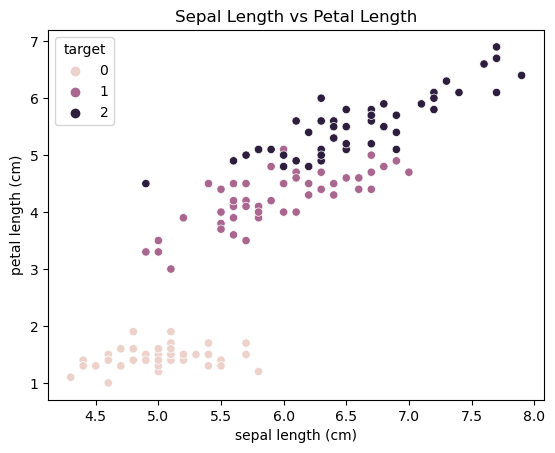

In [54]:
# ==========================================
# 7. Visualization
# ==========================================

sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="target"
)

plt.title("Sepal Length vs Petal Length")
plt.show()



In [56]:

# ==========================================
# 8. X and y
# ==========================================

X = df.drop("target", axis=1)

y = df["target"]



In [58]:

# ==========================================
# 9. Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [60]:

# ==========================================
# 10. Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



In [62]:

# ==========================================
# 11. Build KNN Model
# ==========================================

knn = KNeighborsClassifier(
    n_neighbors=5
)



In [64]:

# ==========================================
# 12. Train Model
# ==========================================

knn.fit(
    X_train_scaled,
    y_train
)



KNeighborsClassifier()

In [66]:

# ==========================================
# 13. Prediction
# ==========================================

y_pred = knn.predict(X_test_scaled)



In [68]:

# ==========================================
# 14. Evaluation
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)



Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



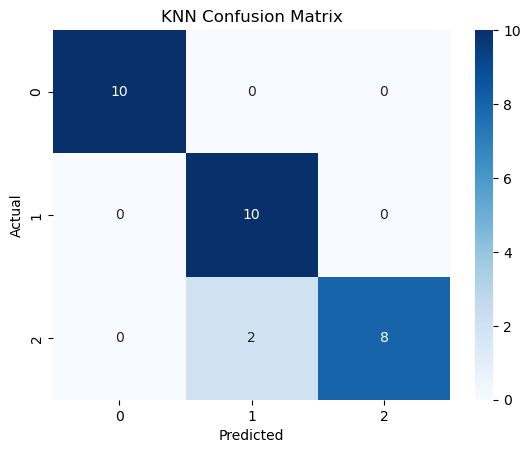

In [70]:

# ==========================================
# 15. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

# 7. Explanation of Example 1

#### Load data
* iris = load_iris()

#### Loads the Iris dataset.

### Create DataFrame
* df = pd.DataFrame(
*     iris.data,
*     columns=iris.feature_names
* )

###### Converts the dataset into a pandas DataFrame.

##### X
* X = df.drop("target", axis=1)

* X contains input features.

##### y
* y = df["target"]

#### y contains the target.



#### Scaling
* scaler.fit_transform(X_train)

###### Learns scaling parameters from training data and transforms it.

* scaler.transform(X_test)

Uses the same parameters on test data.

#### Create model
* KNeighborsClassifier(n_neighbors=5)

#### KNN considers 5 nearest neighbors.

#### Training
* knn.fit(X_train_scaled, y_train)

* KNN is sometimes described as a lazy learner because it doesn't learn a traditional set of model coefficients during .fit(); it stores the training data and performs neighbor calculations when making predictions.

# Example 2 — KNN Classification: Diabetes

### Problem Statement

##### Predict whether a patient has diabetes using medical measurements.

###### Example features:

* Pregnancies
* Glucose
* BloodPressure
* SkinThickness
* Insulin
* BMI
* Age

### Target:

* 0 = No Diabetes
* 1 = Diabetes

# Complete Code

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)




In [115]:
# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/Simplilearn-Edu/Data-Science-Capstone-Projects/refs/heads/master/health%20care%20diabetes.csv")



In [117]:

# Understand dataset
#print(df.head())


df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [119]:
print(df.shape)



(768, 9)


In [121]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [123]:
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [125]:

# Missing values
print(df.isnull().sum())




Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [127]:
# Check target
print(df["Outcome"].value_counts())




Outcome
0    500
1    268
Name: count, dtype: int64


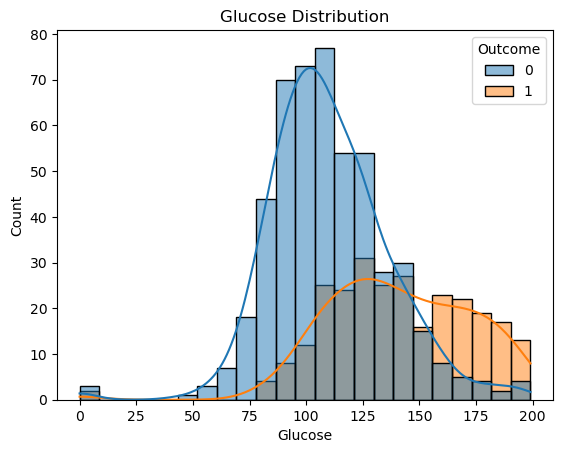

In [129]:
# Visualization
sns.histplot(
    data=df,
    x="Glucose",
    hue="Outcome",
    kde=True
)

plt.title("Glucose Distribution")
plt.show()



Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



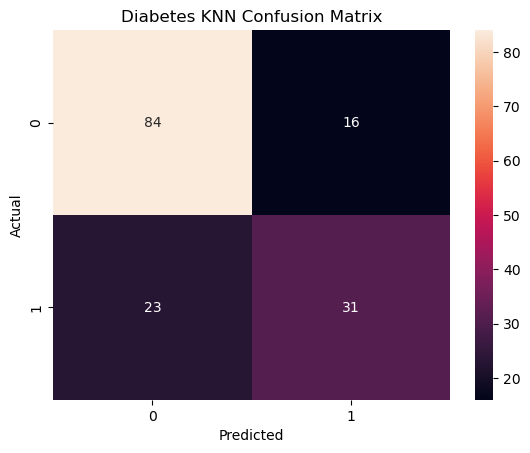

In [131]:

# X and y
X = df.drop("Outcome", axis=1)

y = df["Outcome"]


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# KNN
knn = KNeighborsClassifier(
    n_neighbors=7
)


# Train
knn.fit(
    X_train_scaled,
    y_train
)


# Predict
y_pred = knn.predict(
    X_test_scaled
)


# Accuracy
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)


# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)


# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Diabetes KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# What you practice here

* This example teaches:

# Example 3 — KNN Classification: Customer Churn
* Problem Statement

#### Predict whether a customer will leave a company.

# Example:

* Age
* Monthly Charges
* Tenure
* Total Charges

# Target:

* Churn

In [191]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score




In [193]:
# =====================================
# Load
# =====================================

df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQf4-ZsFxT7EVopR4s_InKnK-TFzutYjG0aDbO3ZyOFe47mA8JqeNVo1AdRjQwpFyGNriPgi188rFKV/pub?gid=1729630511&single=true&output=csv")




In [199]:
# =====================================
# Inspect
# =====================================

# print(df.head())

# print(df.info())

# print(df.isnull().sum())

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2865980,43,Male,42,8,8,25,Standard,Annual,136.99,23,1
1,2620238,23,Female,60,12,5,3,Basic,Annual,843.14,17,1
2,4434988,58,Male,54,10,0,10,Standard,Quarterly,429.39,27,0
3,8341795,47,Male,35,6,9,24,Premium,Quarterly,639.84,24,1
4,5485334,26,Male,45,21,4,1,Basic,Quarterly,761.42,13,0


In [203]:

# =====================================
# Select features
# =====================================

features = [
    "Age",
#    "MonthlyCharges",
    "Tenure",
#     "TotalCharges"
    "Total Spend"
]

X = df[features]

y = df["Churn"]



In [211]:
# df["Churn"].map({
#      "No": 0,
#     "Yes": 1
# })



0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
999995   NaN
999996   NaN
999997   NaN
999998   NaN
999999   NaN
Name: Churn, Length: 1000000, dtype: float64

In [205]:

# =====================================
# Convert target
# =====================================

y = y.map({
    "No": 0,
    "Yes": 1
})



In [213]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2865980,43,Male,42,8,8,25,Standard,Annual,136.99,23,1
1,2620238,23,Female,60,12,5,3,Basic,Annual,843.14,17,1
2,4434988,58,Male,54,10,0,10,Standard,Quarterly,429.39,27,0
3,8341795,47,Male,35,6,9,24,Premium,Quarterly,639.84,24,1
4,5485334,26,Male,45,21,4,1,Basic,Quarterly,761.42,13,0


In [207]:

# =====================================
# Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# =====================================
# Scale
# =====================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# =====================================
# Model
# =====================================

model = KNeighborsClassifier(
    n_neighbors=9,
    weights="distance"
)


# =====================================
# Train
# =====================================

model.fit(
    X_train,
    y_train
)


# =====================================
# Predict
# =====================================

predictions = model.predict(X_test)


# =====================================
# Evaluate
# =====================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

ValueError: Input y contains NaN.

### Important concept

##### Here:

*  weights="distance"

### means closer customers have more influence on the prediction.

# Example 4 — KNN Regression: House Price Prediction

* KNN isn't only for classification.

#### It can also perform regression.

#### Problem Statement

* Predict house price based on house characteristics.

### Features:

* Area
* Bedrooms
* Bathrooms
* Age

#### Target:

* Price

# 8. Understanding KNN Regression

## Example 5 — KNN with Hyperparameter Tuning

* This is the example you should study carefully because it introduces a more realistic ML workflow.

#### Problem Statement
* Find an appropriate value of K instead of simply choosing K = 5.

* We'll use Iris.

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ==========================================
# 1. Load Dataset
# ==========================================

iris = load_iris()


# ==========================================
# 2. Create DataFrame
# ==========================================

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target


# ==========================================
# 3. X / y
# ==========================================

X = df.drop(
    "target",
    axis=1
)

y = df["target"]


# ==========================================
# 4. Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 5. Pipeline
# ==========================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])


# ==========================================
# 6. Parameter Grid
# ==========================================

param_grid = {

    "knn__n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        13,
        15
    ],

    "knn__weights": [
        "uniform",
        "distance"
    ],

    "knn__metric": [
        "euclidean",
        "manhattan"
    ]
}


# ==========================================
# 7. Grid Search
# ==========================================

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)


# ==========================================
# 8. Train
# ==========================================

grid_search.fit(
    X_train,
    y_train
)


# ==========================================
# 9. Best Parameters
# ==========================================

print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)


# ==========================================
# 10. Best CV Score
# ==========================================

print(
    "Best CV Score:",
    grid_search.best_score_
)


# ==========================================
# 11. Test Prediction
# ==========================================

y_pred = grid_search.predict(
    X_test
)


# ==========================================
# 12. Test Accuracy
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Test Accuracy:",
    accuracy
)


# ==========================================
# 13. Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==========================================
# 14. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

Best Parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best CV Score: 0.9666666666666668
Test Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


### 9. Why Use Pipeline?

### Instead of manually doing:

scaler.fit_transform(X_train)

scaler.transform(X_test)

knn.fit(...)

### we can create:

Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# This connects preprocessing and modeling into one workflow.

# It is especially useful during cross-validation because the scaling operation is fitted separately within each training fold rather than leaking information from validation folds.

# 10. How to Select the Best K?


# 11. What Happens When K Is Too Small?

### Suppose:

* K = 1

## The model looks at only one neighbor.

### This can make the model very sensitive to noise.

### Potential problem:

* Overfitting

###The model may learn the training data too closely.

# 12. What Happens When K Is Too Large?

# 13. KNN Bias-Variance Intuition

# 14. Euclidean vs Manhattan Distance
* Euclidean



Straight-line distance:

$$ d=\sqrt{\sum(x_i-y_i)^2} $$

Python:

KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)
Manhattan

Distance along dimensions:

$$ d=\sum|x_i-y_i| $$

Python:

KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan"
)
15. KNN Workflow in Detail

# 15. KNN Workflow in Detail
#### Step 1 — Problem Understanding

### Ask:

* What are we predicting?
* s it classification or regression?
* What are the features?
* What is the target?
* What metric matters?

### Example:

* Predict customer churn

### Target:

* Churn

# Type:

* Classification

# Step 2 — Load Data


df = pd.read_csv("data.csv")

# Step 3 — Understand Data
* df.head()
* df.tail()
* df.shape
* df.info()
* df.describe()
* df.columns

# Step 4 — Data Cleaning

#### Check:

* df.isnull().sum()

#### Duplicates:

* df.duplicated().sum()

#### Remove duplicates:

* df = df.drop_duplicates()

# Step 5 — EDA

### Numerical:

* df.describe()

### Categorical:

* df["Gender"].value_counts()

### Correlation:

* df.corr(numeric_only=True)

## Step 6 — Visualization

### For KNN, useful visualizations include:

* Scatter plot

# Step 7 — Feature Engineering

# Step 8 — X / y Separation

# Step 9 — Train/Test Split

# Step 10 — Scaling

* Very important for KNN:

# Step 11 — Build Model

# Step 12 — Train

In [ ]:

model.fit(
    X_train_scaled,
    y_train
)


# Step 13 — Predict

# Step 14 — Evaluate

# 16. KNN Classification vs Regression

| Feature    | KNN Classification     | KNN Regression           |
| ---------- | ---------------------- | ------------------------ |
| Target     | Category               | Number                   |
| Class      | `KNeighborsClassifier` | `KNeighborsRegressor`    |
| Example    | Spam/Not Spam          | House Price              |
| Prediction | Majority vote          | Average/weighted average |
| Accuracy   | Common metric          | Not normally used        |
| MAE        | Usually not primary    | Common                   |
| RMSE       | Usually not primary    | Common                   |
| R²         | No                     | Yes                      |


# 17. Advantages of KNN


# 18. Disadvantages of KNN
* 1. Computationally expensive during prediction

######  For a large dataset, finding neighbors can be expensive.

* 2. Sensitive to feature scaling

###### This is extremely important.

3. Sensitive to irrelevant features

###### If you include unnecessary variables, distance calculations can become less meaningful.

4. Sensitive to K

###### Bad K can cause:

* Overfitting

#### or:

* Underfitting
  
#### 5. High-dimensional data can be problematic

This relates to the curse of dimensionality.

As the number of dimensions increases, distance-based similarity can become less informative.

#### 19. KNN Interview Questions You Should Practice

#### Q1. What is KNN?

* KNN is a supervised, instance-based learning algorithm that predicts using nearby training observations.

### Q2. Is KNN supervised or unsupervised?
* Supervised

* because it uses labeled training data.

#### Q3. Is KNN parametric or non-parametric?
* Non-parametric

* It doesn't assume a fixed mathematical form for the underlying relationship.

### Q4. Why is scaling important?

* Because KNN relies on distance, and features with larger numerical scales can dominate the distance.

### Q5. What happens when K = 1?

* The closest training observation determines the prediction.

### Q6. What happens if K is very large?

* Predictions become more influenced by a broad neighborhood and can become overly smooth.

### Q7. What is the difference between uniform and distance weights?
* weights="uniform"

* All neighbors have equal weight.

* weights="distance"

* Closer neighbors receive greater weight.

#### Q8. Can KNN be used for regression?

* Yes.

* KNeighborsRegressor()
### Q9. Which distance is commonly used?

* Euclidean distance is a common choice.

### Q10. Why do we split before scaling?

* To prevent information from the test set influencing the scaling parameters.

#### 20. Your KNN Practice Roadmap

* Since you're practicing complete ML workflows, I recommend doing these 5 projects in order:








# Project 1 — Iris Classification

### Practice:

* Dataset
* EDA
* Visualization
* Train/Test
* Scaling
* KNN
* Confusion Matrix
* Classification Report

# Project 2 — Diabetes Classification

### Add:

* Missing values
* Class imbalance
* Feature analysis
* Recall
* Precision
* F1

# Project 3 — Customer Churn

####  Add:

* Categorical encoding
* Feature engineering
* Scaling
* KNN
* Confusion matrix

# Project 4 — House Price Regression

# Practice:

* Regression
* KNN Regressor
* MAE
* MSE
* RMSE
* R²

# Project 5 — KNN Hyperparameter Tuning

### Practice:

* Pipeline
* Cross Validation
* GridSearchCV
* K selection
* Distance metrics
* Weights
* Final model


# The most important KNN concepts to master are:


# If you understand those concepts and can implement the five projects above without copying the code, you will have a strong practical foundation in KNN.